# Project: online bookstore sales data exploratoration



In [1]:
# importation de pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importation des fichiers CSV

customers = pd.read_csv('data/customers.csv', sep=';')
products = pd.read_csv('data/products.csv', sep=';')
transactions = pd.read_csv('data/Transactions.csv', sep=';')


/tmp/ipython-input-1283835852.py:11: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  transactions = pd.read_csv('data/Transactions.csv', sep=';')


In [2]:
# Functions to use and reuse

# display the columns
def display_columns_value_counts(df=None):
  """ Take a dataframe and print all the values in the columns"""
  if df is None:
    df = pd.DataFrame()
  else :
    for col in df.columns:
      print(df[col].value_counts(dropna=False))

# Calculate the iqr, lower and upper
def calculate_iqr(df=None, column=None):
  """ Calculate the iqr, lower and upper for a column"""
  if df is None:
    df = pd.DataFrame()
  else:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_whisker = Q1 - 1.5 * IQR
    upper_whisker = Q3 + 1.5 * IQR
    return IQR, lower_whisker, upper_whisker

# Turn the month number to a month name for a better visual on the plot
def month_number_to_name(month_number):
  """ Take a month number and turn it into an ordered category to be displayed on the plot """
  map_months_name = {
    1: 'Janvier', 2: 'Février', 3: 'Mars', 4: 'Avril', 5: 'Mai', 6: 'Juin',
    7: 'Juillet', 8: 'Août', 9: 'Septembre', 10: 'Octobre', 11: 'Novembre', 12: 'Décembre'
  }

  month_order = ['Janvier', 'Février', 'Mars', 'Avril', 'Mai', 'Juin', 'Juillet', 'Août', 'Septembre', 'Octobre', 'Novembre', 'Décembre']
  month_name = month_number.map(map_months_name).astype('category').cat.reorder_categories(
    new_categories=month_order,
    ordered=True)
  return month_name

## Exploration du jeu de données "Customers"




In [3]:
customers.info()

display_columns_value_counts(customers)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8621 non-null   object
 1   sex        8621 non-null   object
 2   birth      8621 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB
client_id
c_84      1
c_4410    1
c_7839    1
c_1699    1
c_5961    1
         ..
c_5019    1
c_8203    1
c_4701    1
c_2322    1
c_2998    1
Name: count, Length: 8621, dtype: int64
sex
f    4490
m    4131
Name: count, dtype: int64
birth
2004    440
1979    215
1988    207
1986    203
1978    199
       ... 
1935      8
1932      6
1931      4
1930      4
1929      3
Name: count, Length: 76, dtype: int64


In [4]:
# Number of uniques values of the id
print(f"Number of unique ids {customers['client_id'].nunique()} over {len(customers)} rows")

# Problèmes de formattage
ids_not_formatted = customers['client_id'].str.contains('c_').count()
print(f'Lines well formatted : {ids_not_formatted}')

Number of unique ids 8621 over 8621 rows
Lines well formatted : 8621


In [5]:
# est-ce qu'il y a des valeurs nulles dans la date
print(f'Nombre de valeurs nulles dans l\'année de naissance : {customers["birth"].isnull().sum()}')

Nombre de valeurs nulles dans l'année de naissance : 0


## Exploration du jeu de données "Transactions"



In [6]:
transactions.info()

print(transactions.head())

display_columns_value_counts(transactions)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     687534 non-null  object
 1   date        687534 non-null  object
 2   session_id  687534 non-null  object
 3   client_id   687534 non-null  object
dtypes: object(4)
memory usage: 32.0+ MB
  id_prod                        date session_id client_id
0  0_1259  2021-03-01 00:01:07.843138        s_1     c_329
1  0_1390  2021-03-01 00:02:26.047414        s_2     c_664
2  0_1352  2021-03-01 00:02:38.311413        s_3     c_580
3  0_1458  2021-03-01 00:04:54.559692        s_4    c_7912
4  0_1358  2021-03-01 00:05:18.801198        s_5    c_2033
id_prod
NaN       361041
1_369       2340
1_417       2269
1_414       2246
1_498       2202
           ...  
0_807          1
0_1284         1
2_23           1
0_833          1
0_1683         1
Name: count, Length: 3266, dtype: int64
date
NaN    

In [7]:
# exploration du champs id_prod, session_id et client_id qui semblent être la clé primaires
transactions_id = transactions[['id_prod', 'session_id', 'client_id']]

# Duplicated number of lines
print(f'Nombre de lignes avec un id dupliqué : {transactions_id.duplicated().sum()}')

duplicated_lignes = transactions_id[transactions_id.duplicated(keep=False)]
print(duplicated_lignes)

Nombre de lignes avec un id dupliqué : 361895
        id_prod session_id client_id
988       1_483      s_504    c_3678
999       1_483      s_504    c_3678
1233     0_1453      s_634    c_5603
1264     0_1453      s_634    c_5603
2363     0_1158     s_1172    c_7732
...         ...        ...       ...
1048570     NaN        NaN       NaN
1048571     NaN        NaN       NaN
1048572     NaN        NaN       NaN
1048573     NaN        NaN       NaN
1048574     NaN        NaN       NaN

[362749 rows x 3 columns]


In [8]:
# delete the nulls and the ids that are duplicated
transactions.drop_duplicates(subset=['id_prod', 'session_id', 'client_id'], inplace=True)
transactions.dropna(subset=['id_prod', 'session_id', 'client_id'], inplace=True)

In [9]:
# see if there are ids bad formated
client_id_formated = transactions['client_id'].str.startswith('c_').sum()
session_id_formated = transactions['session_id'].str.startswith('s_').sum()
id_prod_formated = transactions['id_prod'].str.startswith(('0_', '1_', '2_')).sum()

# see the format of all
print(f"Identifiants clients bien formatés : {client_id_formated} over {len(transactions['client_id'])}")
print(f"Identifiants sessions bien formatés : {session_id_formated} over {len(transactions['session_id'])}")
print(f"Identifiants produits bien formatés : {id_prod_formated} over {len(transactions['id_prod'])}")

# the contrary of .contains
# identifiants mal formatés
# not contains

Identifiants clients bien formatés : 686679 over 686679
Identifiants sessions bien formatés : 686679 over 686679
Identifiants produits bien formatés : 686679 over 686679


In [10]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 686679 entries, 0 to 687533
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     686679 non-null  object
 1   date        686679 non-null  object
 2   session_id  686679 non-null  object
 3   client_id   686679 non-null  object
dtypes: object(4)
memory usage: 26.2+ MB


In [11]:
# deletion of the timestamp to get a normal date
transactions['date'] = pd.to_datetime(transactions['date'], errors='coerce').dt.date

transactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 686679 entries, 0 to 687533
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     686679 non-null  object
 1   date        686679 non-null  object
 2   session_id  686679 non-null  object
 3   client_id   686679 non-null  object
dtypes: object(4)
memory usage: 26.2+ MB


## Exploration du jeu de données "Products"

In [12]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3286 non-null   object 
 1   price    3286 non-null   float64
 2   categ    3286 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.1+ KB


In [13]:
products.head()

,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0


In [14]:
display_columns_value_counts(products)

id_prod
0_1920    1
0_1421    1
0_1368    1
0_731     1
1_587     1
         ..
2_228     1
0_389     1
0_1915    1
0_2157    1
1_463     1
Name: count, Length: 3286, dtype: int64
price
4.99     85
6.99     84
3.99     80
5.99     78
8.99     74
         ..
4.50      1
23.19     1
13.18     1
6.80      1
15.08     1
Name: count, Length: 1454, dtype: int64
categ
0    2308
1     739
2     239
Name: count, dtype: int64


In [15]:
# Not nulls and duplicated ids
print(f'Number of duplicated lines : {products["id_prod"].duplicated().sum()}')
print(f'Number of nulls: {products["id_prod"].isnull().sum()}')

Number of duplicated lines : 0
Number of nulls: 0


In [16]:
# change the name and switch the type to category
products = products.rename(columns={'categ': 'category'})
products['category'] = products['category'].astype('category')
products['category'] = products['category'].cat.reorder_categories(
    new_categories=[0, 1, 2], ordered=True
)
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   id_prod   3286 non-null   object  
 1   price     3286 non-null   float64 
 2   category  3286 non-null   category
dtypes: category(1), float64(1), object(1)
memory usage: 54.8+ KB


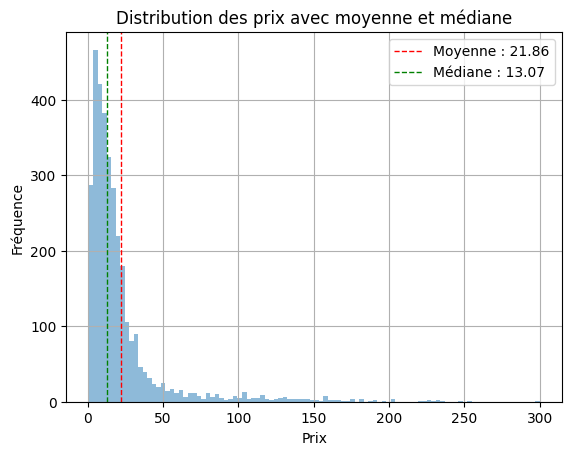

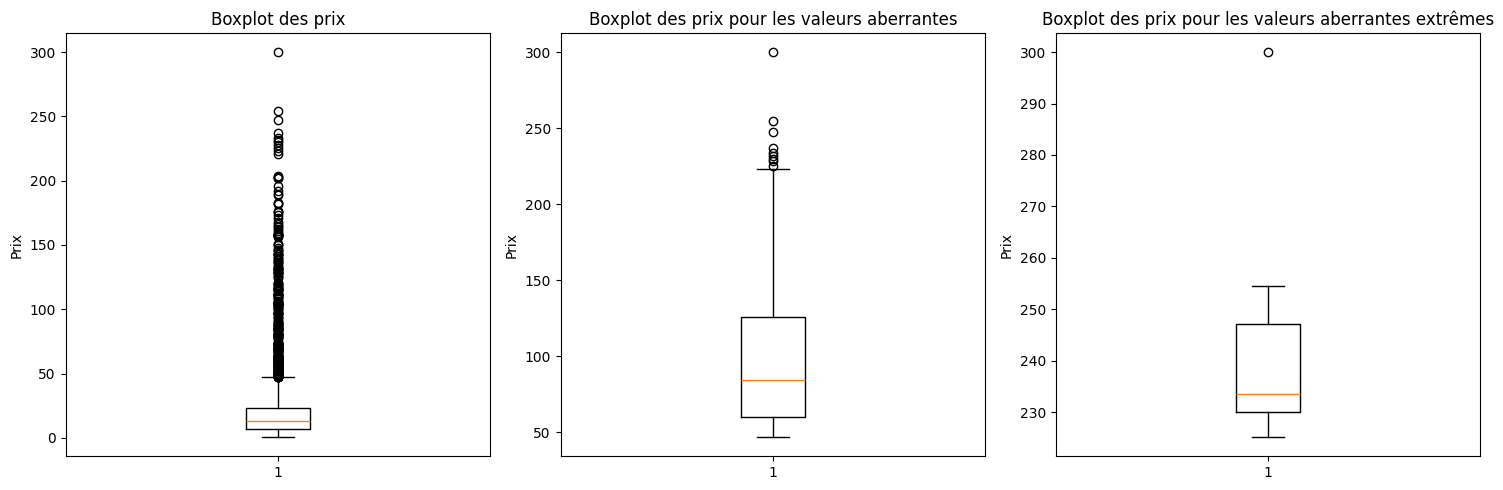

In [17]:
# Calculate mean and median
mean_price = products['price'].mean()
median_price = products['price'].median()

# Add vertical lines for mean and median
plt.axvline(mean_price, color='red', linestyle='dashed', linewidth=1, label=f'Moyenne : {mean_price:.2f}')
plt.axvline(median_price, color='green', linestyle='dashed', linewidth=1, label=f'Médiane : {median_price:.2f}')

# What are the prices which are displayed
products['price'].hist(bins=100, alpha=0.5)
plt.xlabel('Prix')
plt.ylabel('Fréquence')
plt.title('Distribution des prix avec moyenne et médiane')
plt.legend()
plt.show()

# Calculate the iqr if the products are not empty
if not products.empty:
  iqr, lower_whisker, upper_whisker = calculate_iqr(products, 'price')
  outliers = products[products['price'] > upper_whisker]

# Calculate the iqr for the outliers are not empty
if not outliers.empty:
  iqr_outliers, lower_whisper_outliers, upper_whisker_outliers = calculate_iqr(outliers, 'price')
  outliers_beyond = outliers[outliers['price'] > upper_whisker_outliers]


levels = [products, outliers, outliers_beyond]
fig, ax = plt.subplots(1, len(levels), figsize=(15, 5))
for i, data in enumerate(levels):
  if not data.empty:
    ax[i].boxplot(data=data, x='price')
    if i == 0:
      title = 'Boxplot des prix'
    elif i == 1:
      title = 'Boxplot des prix pour les valeurs aberrantes'
    else:
      title = 'Boxplot des prix pour les valeurs aberrantes extrêmes'
    ax[i].set_title(title)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('Prix')
  else:
    ax[i].set_visible(False)


plt.tight_layout()

plt.show()

## Fusion "Customers" et "Transactions"

In [18]:
# check if all the ids match or if there are some null values
customers_transactions_df = pd.merge(transactions, customers, on='client_id', how='left')

In [19]:
customers_transactions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 686679 entries, 0 to 686678
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     686679 non-null  object
 1   date        686679 non-null  object
 2   session_id  686679 non-null  object
 3   client_id   686679 non-null  object
 4   sex         686679 non-null  object
 5   birth       686679 non-null  int64 
dtypes: int64(1), object(5)
memory usage: 31.4+ MB


## Fusion précédente et "products"

In [20]:
# check if there are some null values with the ids from products
customers_transactions_products_df = pd.merge(customers_transactions_df, products, on='id_prod', how='left')

In [21]:
customers_transactions_products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 686679 entries, 0 to 686678
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   id_prod     686679 non-null  object  
 1   date        686679 non-null  object  
 2   session_id  686679 non-null  object  
 3   client_id   686679 non-null  object  
 4   sex         686679 non-null  object  
 5   birth       686679 non-null  int64   
 6   price       686679 non-null  float64 
 7   category    686679 non-null  category
dtypes: category(1), float64(1), int64(1), object(5)
memory usage: 37.3+ MB


# Analyse du chiffre d'affaires

## Chiffre d'affaires total

In [22]:
global_turnover = customers_transactions_products_df['price'].sum()
print(f'Le CA total est de {global_turnover: .2f} euros')

customers_transactions_products_df.info()

Le CA total est de  12009918.53 euros
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 686679 entries, 0 to 686678
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   id_prod     686679 non-null  object  
 1   date        686679 non-null  object  
 2   session_id  686679 non-null  object  
 3   client_id   686679 non-null  object  
 4   sex         686679 non-null  object  
 5   birth       686679 non-null  int64   
 6   price       686679 non-null  float64 
 7   category    686679 non-null  category
dtypes: category(1), float64(1), int64(1), object(5)
memory usage: 37.3+ MB


## Évolution du chiffre d'affaires dans le temps

Le chiffre d'affaires a diminué au cours des deux dernières années et a chuté encore plus fortement en 2023. Comment cela a-t-il pu arriver ?

In [23]:
# Convert the 'date' column to datetime objects
customers_transactions_products_df['date'] = pd.to_datetime(customers_transactions_products_df['date'])

# split the date into several time periods
customers_transactions_products_df['day'] = customers_transactions_products_df['date'].dt.day
customers_transactions_products_df['year'] = customers_transactions_products_df['date'].dt.year
customers_transactions_products_df['month'] = customers_transactions_products_df['date'].dt.month

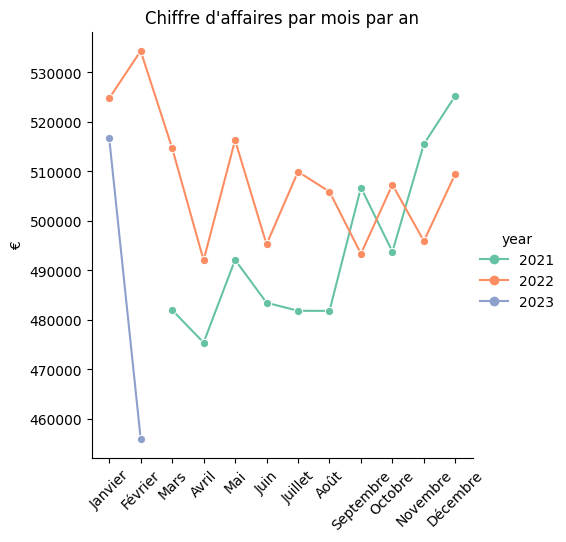

In [24]:
# turnover per month
turnover_per_month = customers_transactions_products_df.groupby(['year', 'month'], as_index=False)['price'].agg(
    total_turnover='sum'
)
turnover_per_month = turnover_per_month.sort_values(['year', 'month'], ascending=True)

# Rolling avg
turnover_per_month['rolling_avg'] = turnover_per_month['total_turnover'].rolling(window=12, min_periods=1).mean()

turnover_per_month['month_name'] = month_number_to_name(turnover_per_month['month'])


sns.relplot(x='month_name', y='total_turnover', hue='year', data=turnover_per_month, kind='line', palette='Set2', marker='o')
plt.xlabel('')
plt.ylabel('€')
plt.title('Chiffre d\'affaires par mois par an')
plt.xticks(rotation=45)
plt.show()

## Décomposition de la moyenne mobile du chiffre d'affaires

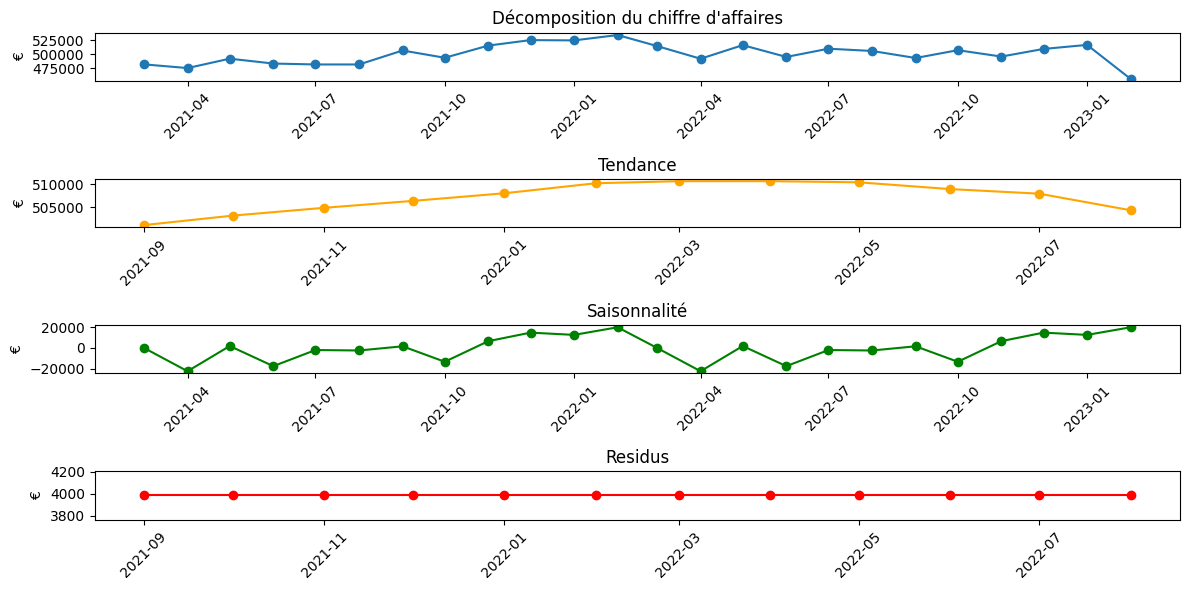

In [25]:
from statsmodels.tsa.seasonal import seasonal_decompose

turnover_per_month_cp = turnover_per_month.copy()

turnover_per_month_cp["date"] = pd.to_datetime(turnover_per_month_cp["year"].astype(str) + "-" + turnover_per_month_cp["month"].astype(str) + "-01")

turnover_per_month_cp.set_index("date", inplace=True)

decomposition = seasonal_decompose(turnover_per_month_cp['total_turnover'], model='additive', period=12)


# decomposition of all the various data that will ploted
original = decomposition.observed
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

plt.figure(figsize=(12, 6))

for i, data in enumerate([original, trend, seasonal, residual]):
  plt.subplot(4, 1, i + 1)
  if i == 0:
    plt.title("Décomposition du chiffre d'affaires")
    plt.plot(data, label="Chiffre d\'affaires original", marker="o")
  elif i==1:
    plt.title("Tendance")
    plt.plot(data, label="Tendance", color="orange", marker="o")
  elif i==2:
    plt.title("Saisonnalité")
    plt.plot(data, label="Saisonnalité", color="green", marker="o")
  else:
    plt.title("Residus")
    plt.plot(data, label="Résidus", color="red", marker="o")
  plt.xticks(rotation=45)
  plt.ylabel("€")
plt.subplots_adjust(hspace=0.5)
plt.tight_layout()
plt.show()


/tmp/ipython-input-1176166406.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


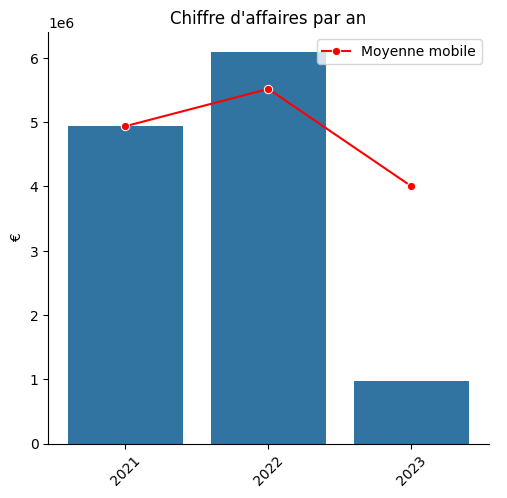

In [26]:
# turnover per year
turnover_per_year = customers_transactions_products_df.groupby('year', as_index=False)['price'].agg(
    total_turnover='sum',
)

turnover_per_year['rolling_avg'] = turnover_per_year['total_turnover'].rolling(min_periods=1, window=3).mean()

turnover_per_year = turnover_per_year.sort_values('year', ascending=True)
turnover_per_year['year'] = turnover_per_year['year'].astype('str')
g = sns.catplot(x='year',
                 y='total_turnover',
                 data=turnover_per_year,
                 kind='bar')

for ax in g.axes.flat:
  sns.lineplot(x='year',
               y='rolling_avg',
               data=turnover_per_year,
               ax=ax,
               color='red',
               marker='o',
               label="Moyenne mobile")
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
g.ax.set_title('Chiffre d\'affaires par an')
g.ax.set_xlabel('')
g.ax.set_ylabel('€')
plt.show()

# Chiffre d'affaires par catégorie

/tmp/ipython-input-2791846527.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  turnover_per_category = customers_transactions_products_df.groupby(['year', 'month', 'category'], as_index=False)['price'].sum()
/tmp/ipython-input-2791846527.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45)
/tmp/ipython-input-2791846527.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45)
/tmp/ipython-input-2791846527.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or 

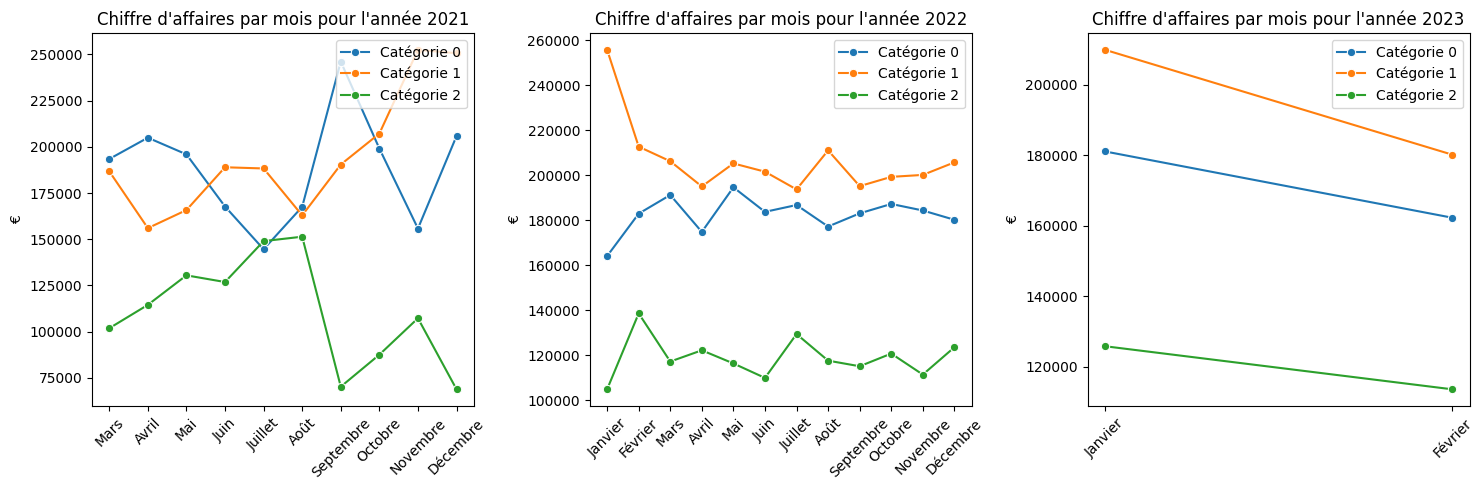

/tmp/ipython-input-2791846527.py:33: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.catplot(data=turnover_per_category,


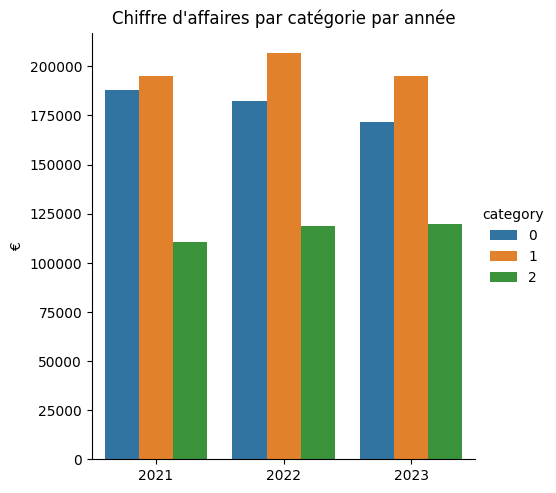

In [27]:
# turnover per category
turnover_per_category = customers_transactions_products_df.groupby(['year', 'month', 'category'], as_index=False)['price'].sum()
turnover_per_category.sort_values('category', ascending=True, inplace=True)

turnover_per_category['month_name'] = month_number_to_name(turnover_per_category['month'])

# To avoid showing the month where there is no data
turnover_per_category.loc[turnover_per_category['price'] == 0, 'price'] = np.nan

fig, ax = plt.subplots(1, turnover_per_category['year'].nunique(), figsize=(15, 5))

for i, year in enumerate(turnover_per_category['year'].unique()):
  data_category = turnover_per_category[turnover_per_category["year"] == year]

  ax[i].set_title(f'Chiffre d\'affaires par mois pour l\'année {year}')
  sns.lineplot(data=data_category,
               x='month_name', y='price',
               hue="category",
               marker='o',
               ax=ax[i])
  ax[i].set_xlabel('')
  ax[i].set_ylabel('€')

  # Customize the legend labels
  handles, labels = ax[i].get_legend_handles_labels()
  ax[i].legend(handles, ['Catégorie ' + label for label in labels], loc='upper right')
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45)
  plt.subplots_adjust(wspace=0.8)
plt.tight_layout()
plt.show()


sns.catplot(data=turnover_per_category,
            kind="bar",
            x="year",
            y="price", hue="category",
            ci=False)
plt.title('Chiffre d\'affaires par catégorie par année')
plt.xlabel('')
plt.ylabel('€')
plt.show()

## Evolution du nombre de clients acquis

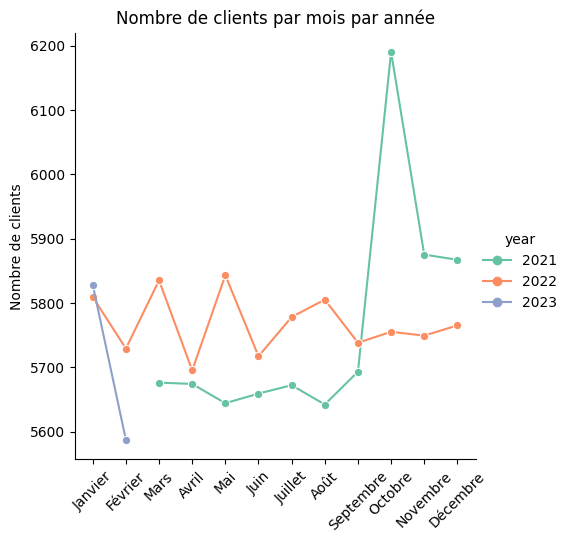

In [28]:
# Number of customers per month
customers_per_month = customers_transactions_products_df.groupby(['year','month'], as_index=False)['client_id'].nunique()
customers_per_month = customers_per_month.sort_values(['year', 'month'], ascending=True)

customers_per_month['month_name'] = month_number_to_name(customers_per_month['month'])

g = sns.relplot(x='month_name',
                 y='client_id',
                hue='year',
                 data=customers_per_month,
                kind='line',
                palette='Set2',
                marker='o')
plt.xlabel('')
plt.ylabel('Nombre de clients')
plt.title('Nombre de clients par mois par année')
plt.xticks(rotation=45)
plt.show()

## Nombre de transactions

The number of transactions is 686679


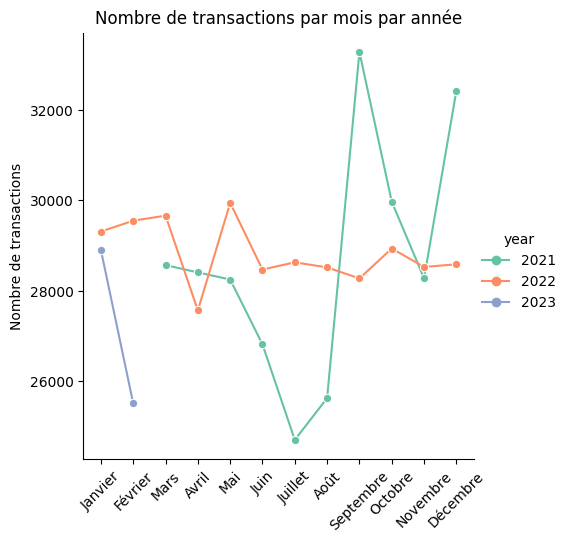

In [29]:
# Number of transactions
number_transactions = customers_transactions_products_df['date'].count()
print(f'The number of transactions is {number_transactions}')

# Number of sales transactions
sales_per_month_year = customers_transactions_products_df.groupby(['year','month'], as_index=False)['date'].count()
sales_per_month_year = sales_per_month_year.sort_values(['year', 'month'], ascending=True)

sales_per_month_year['month_name'] = month_number_to_name(sales_per_month_year['month'])

sns.relplot(kind='line',
            data=sales_per_month_year,
            x='month_name',
            y='date',
            hue='year',
            palette='Set2',
            marker='o')

plt.xlabel('')
plt.ylabel('Nombre de transactions')
plt.title('Nombre de transactions par mois par année')
plt.xticks(rotation=45)
plt.show()

## Nombre de produits vendus dans le temps

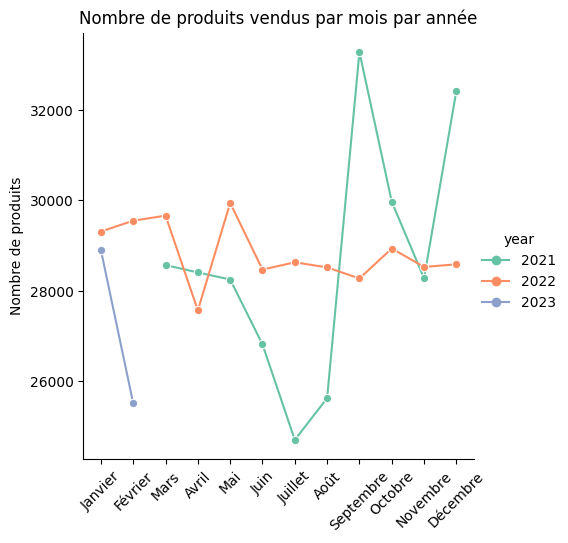

In [30]:
number_products_sold = customers_transactions_products_df.groupby(["year", "month"], as_index=False)['id_prod'].count()\
.sort_values(["year", "month"], ascending=True)

number_products_sold["month_name"] = month_number_to_name(number_products_sold["month"])

sns.relplot(kind='line',
            data=number_products_sold,
            x='month_name',
            y='id_prod',
            hue='year',
            palette='Set2',
            marker='o')

plt.xlabel('')
plt.ylabel('Nombre de produits')
plt.title('Nombre de produits vendus par mois par année')
plt.xticks(rotation=45)
plt.show()

Le nombre de transactions est égal au nombre de produits vendus, ce qui veut dire que chaque transaction enregistré avec une date équivaut à une vente

In [31]:
cross_metrics_year_month = pd.merge(turnover_per_month, sales_per_month_year, on=['year', 'month', 'month_name'], how='left').merge(customers_per_month, on=['year', 'month', 'month_name'], how='left')

In [32]:
cross_metrics_year_month.sort_values(["year", "month"], ascending=True, inplace=True)
cross_metrics_year_month.drop(["rolling_avg", "month"], axis=1, inplace=True)
cross_metrics_year_month.rename(columns={'total_turnover': 'turnover', 'date': 'sales', 'client_id': 'customers'}, inplace=True)

In [33]:
  cross_metrics_year_month['unit_price_sold'] = np.round(cross_metrics_year_month['turnover'] / cross_metrics_year_month['sales'], 2)
  cross_metrics_year_month['sales_per_customer'] = np.round(cross_metrics_year_month['sales'] / cross_metrics_year_month['customers'], 2)
  cross_metrics_year_month['turnover_per_customer'] = np.round(cross_metrics_year_month['turnover'] / cross_metrics_year_month['customers'], 2)


In [34]:
pivot_metrics = cross_metrics_year_month.pivot(index='month_name', columns='year', values=['turnover',
                                                                                            'sales',
                                                                                            'customers',
                                                                                            'unit_price_sold',
                                                                                           'sales_per_customer',
                                                                                   'turnover_per_customer']).fillna(0)

display(pivot_metrics.head(24))

turnover                          sales                    \
year             2021       2022       2023     2021     2022     2023   
month_name                                                               
Janvier          0.00  524749.31  516702.99      0.0  29310.0  28899.0   
Février          0.00  534316.21  455966.92      0.0  29549.0  25509.0   
Mars        481989.86  514699.70       0.00  28568.0  29661.0      0.0   
Avril       475410.58  492051.40       0.00  28405.0  27566.0      0.0   
Mai         492140.59  516291.15       0.00  28249.0  29942.0      0.0   
Juin        483466.03  495260.32       0.00  26814.0  28469.0      0.0   
Juillet     481841.22  509934.24       0.00  24703.0  28629.0      0.0   
Août        481820.70  505892.28       0.00  25626.0  28517.0      0.0   
Septembre   506732.93  493351.43       0.00  33280.0  28272.0      0.0   
Octobre     493769.07  507302.76       0.00  29969.0  28934.0      0.0   
Novembre    515505.83  495915.38       0.00  28276.0  28527.0      0.0   
Décembre    525281.86  509525.77       0.00  32420.0  28585.0      0.0   

           customers                 unit_price_sold                \
year            2021    2022    2023            2021   2022   2023   
month_name                                                           
Janvier          0.0  5809.0  5828.0            0.00  17.90  17.88   
Février          0.0  5729.0  5587.0            0.00  18.08  17.87   
Mars          5676.0  5835.0     0.0           16.87  17.35   0.00   
Avril         5674.0  5695.0     0.0           16.74  17.85   0.00   
Mai           5644.0  5843.0     0.0           17.42  17.24   0.00   
Juin          5659.0  5717.0     0.0           18.03  17.40   0.00   
Juillet       5672.0  5778.0     0.0           19.51  17.81   0.00   
Août          5642.0  5805.0     0.0           18.80  17.74   0.00   
Septembre     5693.0  5738.0     0.0           15.23  17.45   0.00   
Octobre       6190.0  5755.0     0.0           16.48  17.53   0.00   
Novembre      5875.0  5749.0     0.0           18.23  17.38   0.00   
Décembre      5867.0  5765.0     0.0           16.20  17.82   0.00   

           sales_per_customer             turnover_per_customer                
year                     2021  2022  2023                  2021   2022   2023  
month_name                                                                     
Janvier                  0.00  5.05  4.96                  0.00  90.33  88.66  
Février                  0.00  5.16  4.57                  0.00  93.27  81.61  
Mars                     5.03  5.08  0.00                 84.92  88.21   0.00  
Avril                    5.01  4.84  0.00                 83.79  86.40   0.00  
Mai                      5.01  5.12  0.00                 87.20  88.36   0.00  
Juin                     4.74  4.98  0.00                 85.43  86.63   0.00  
Juillet                  4.36  4.95  0.00                 84.95  88.25   0.00  
Août                     4.54  4.91  0.00                 85.40  87.15   0.00  
Septembre                5.85  4.93  0.00                 89.01  85.98   0.00  
Octobre                  4.84  5.03  0.00                 79.77  88.15   0.00  
Novembre                 4.81  4.96  0.00                 87.75  86.26   0.00  
Décembre                 5.53  4.96  0.00                 89.53  88.38   0.00

## Meilleures et pires ventes

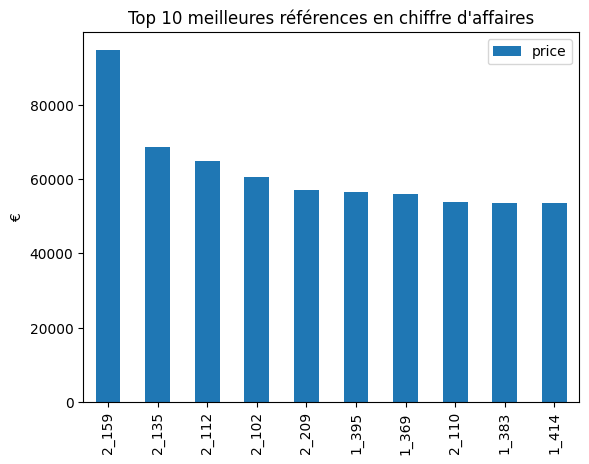

In [35]:
# Tops products
sales_product = customers_transactions_products_df.groupby('id_prod', as_index=False)['price'].sum()
top_references = sales_product.sort_values('price', ascending=False)
top_references = top_references.head(10)
top_references.plot(kind='bar', x='id_prod')
plt.xlabel('')
plt.ylabel('€')
plt.title('Top 10 meilleures références en chiffre d\'affaires')
plt.show()

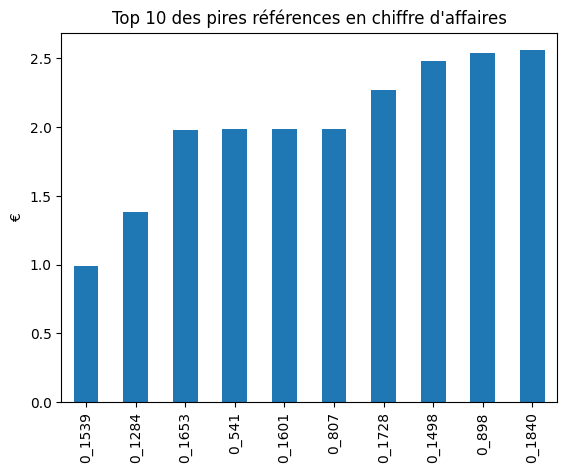

In [36]:
# Worst products
worst_references = sales_product.sort_values('price', ascending=True).head(10)

worst_references.plot(kind='bar',
                      x='id_prod',
                      legend=None)
plt.xlabel('')
plt.ylabel('€')
plt.title('Top 10 des pires références en chiffre d\'affaires')
plt.show()

/tmp/ipython-input-3182485805.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_distribution = customers_transactions_products_df.groupby('category', as_index=False)['price'].sum()


Text(0.5, 1.0, "Répartition du chiffre d'affaires par catégorie")

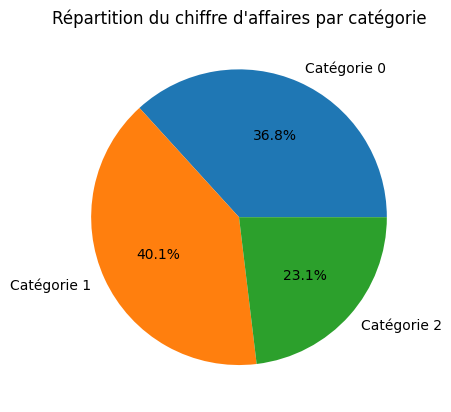

In [37]:
# Category distribution
category_distribution = customers_transactions_products_df.groupby('category', as_index=False)['price'].sum()
category_distribution.plot(kind='pie',
                           y='price',
                           labels=['Catégorie '+ str(cat) for cat in category_distribution["category"].unique()],
                           autopct='%1.1f%%',
                           legend=None)
plt.ylabel('')
plt.title('Répartition du chiffre d\'affaires par catégorie')

# Profils clients

In [38]:
customers_transactions_products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 686679 entries, 0 to 686678
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id_prod     686679 non-null  object        
 1   date        686679 non-null  datetime64[ns]
 2   session_id  686679 non-null  object        
 3   client_id   686679 non-null  object        
 4   sex         686679 non-null  object        
 5   birth       686679 non-null  int64         
 6   price       686679 non-null  float64       
 7   category    686679 non-null  category      
 8   day         686679 non-null  int32         
 9   year        686679 non-null  int32         
 10  month       686679 non-null  int32         
dtypes: category(1), datetime64[ns](1), float64(1), int32(3), int64(1), object(4)
memory usage: 45.2+ MB


## Répartition de la clientèle

In [39]:
# Calculate the age for each customers
age_customer = pd.Timestamp.today().year - customers_transactions_products_df['birth']
customers_transactions_products_df['age'] = age_customer

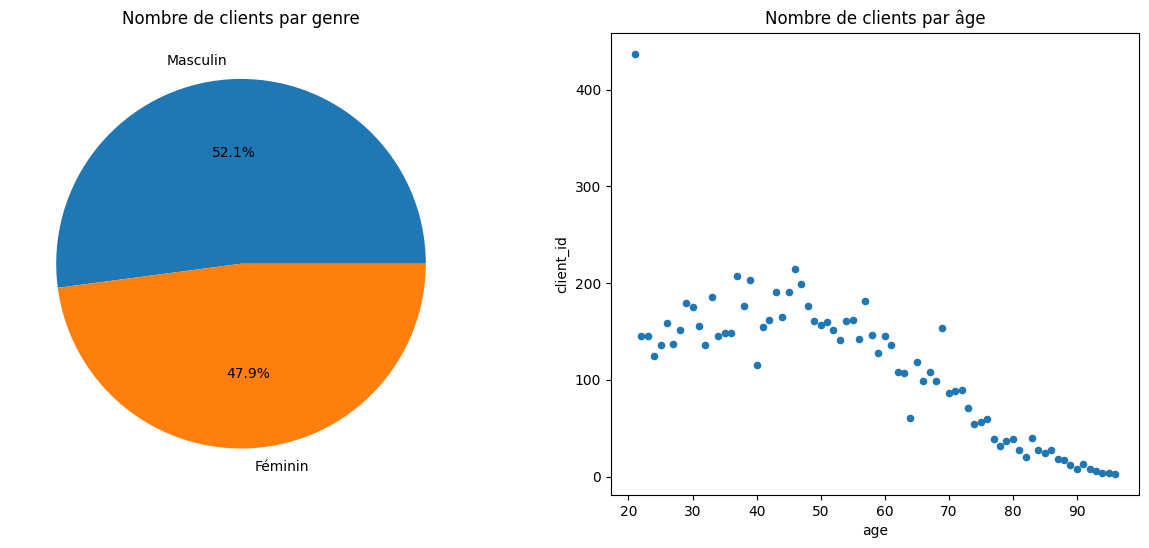

In [40]:
# Number of customers per gender
customers_per_gender = customers_transactions_products_df.groupby('sex', as_index=False)['client_id'].nunique()
customers_per_age = customers_transactions_products_df.groupby('age', as_index=False)['client_id'].nunique()

fig, ax = plt.subplots(1, len([customers_per_gender, customers_per_age]), figsize=(15, 6))

for i, data in enumerate([customers_per_gender, customers_per_age]):
  if i == 0:
    ax[i].set_title('Nombre de clients par genre')
    customers_per_gender.plot(kind='pie',
                              y='client_id',
                              labels=['Masculin', 'Féminin'],
                              autopct='%1.1f%%', legend=None, ax=ax[i])
    ax[i].set_ylabel('')
  else:
    ax[i].set_title('Nombre de clients par âge')
    ax[i].set_xlabel('Âge')
    ax[i].set_ylabel('Nombre de clients')
    customers_per_age.plot(kind='scatter', x='age', y='client_id', ax=ax[i])
plt.show()

## Courbe de Lorenz: définir pour chaque pour % de clients le % de chiffre d'affaires généré

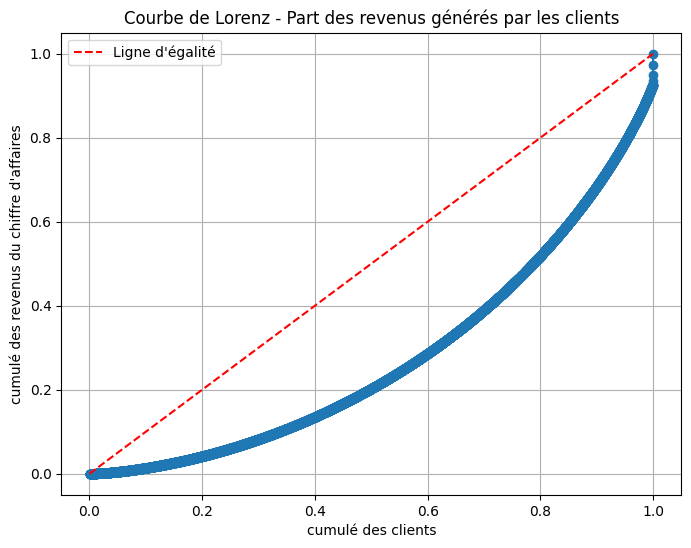

In [41]:
# Calculate the total amount spent per customer
customer_revenue = customers_transactions_products_df.groupby('client_id', as_index=False)['price'].sum()
customer_revenue_srt = customer_revenue.sort_values('price', ascending=True)

# Calculate the cumulative sum of revenue
customer_revenue_srt = customer_revenue_srt['price'].cumsum()

# np.arange : loop from 1 to the last index + 1 to include the last value
cumulative_customer_percentage = np.arange(1, len(customer_revenue_srt) + 1) / len(customer_revenue_srt)

# cumulative revenue / total cumulative revenue (-1 -> last index)
cumulative_revenue_percentage = customer_revenue_srt / customer_revenue_srt.iloc[-1]

# Plot the Lorenz curve
plt.figure(figsize=(8, 6))
plt.plot(cumulative_customer_percentage, cumulative_revenue_percentage, marker='o', linestyle='-')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Ligne d\'égalité') # Line of perfect equality
plt.title('Courbe de Lorenz - Part des revenus générés par les clients')
plt.xlabel('cumulé des clients')
plt.ylabel('cumulé des revenus du chiffre d\'affaires')
plt.grid(True)
plt.legend()
plt.show()

In [42]:
# Look at the percentage of the customers who are making
eighty_percent = customer_revenue['price'].sum() * 0.8

# keep the top customers
# Sort in descending order to get the top spenders
top_80percent = customer_revenue.sort_values('price', ascending=False)

# Calculate the cumulative sum from the highest spenders
top_80percent['cumulative_price'] = top_80percent['price'].cumsum()

# Select customers who contribute to the top 80% of the total turnover
top_80percent = top_80percent[top_80percent['cumulative_price'] <= eighty_percent]

print(f"80% du chiffre d'affaires est généré par {(top_80percent["client_id"].nunique()/customers_transactions_products_df["client_id"].nunique())*100:.2f}% \
de la clientèle totale")

80% du chiffre d'affaires est généré par 50.35% de la clientèle totale


## Définition des clients professionnels : B2B

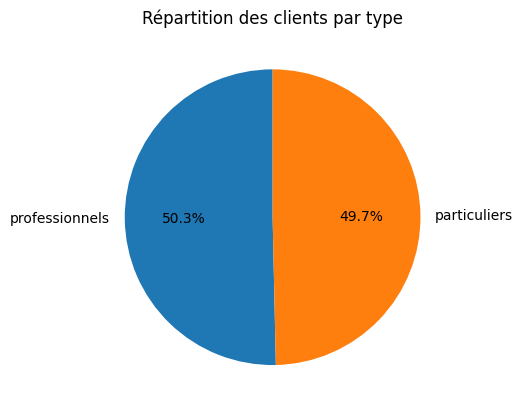

In [43]:
# Turnover for B2B customers

# turnover minimum made by those who generated the more important revenue for the companies
amount_minimum = top_80percent['price'].min()

# compare the turnover to the minimum to determine the type of customers
b2b_customers = customer_revenue[customer_revenue['price'] >= amount_minimum]
b2c_customers = customer_revenue[customer_revenue['price'] < amount_minimum]

plt.pie([len(b2b_customers), len(b2c_customers)],
        labels=['professionnels', 'particuliers'],
        autopct='%1.1f%%',
        startangle=90)
plt.title('Répartition des clients par type')
plt.show()


In [44]:
# specify a label to identify which customer is professional or a particular
customers_transactions_products_df['type_customer'] = np.where(customers_transactions_products_df['client_id'].isin(b2b_customers['client_id']), 'Professionnels', 'Particuliers')

/tmp/ipython-input-4008671912.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45)
/tmp/ipython-input-4008671912.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45)


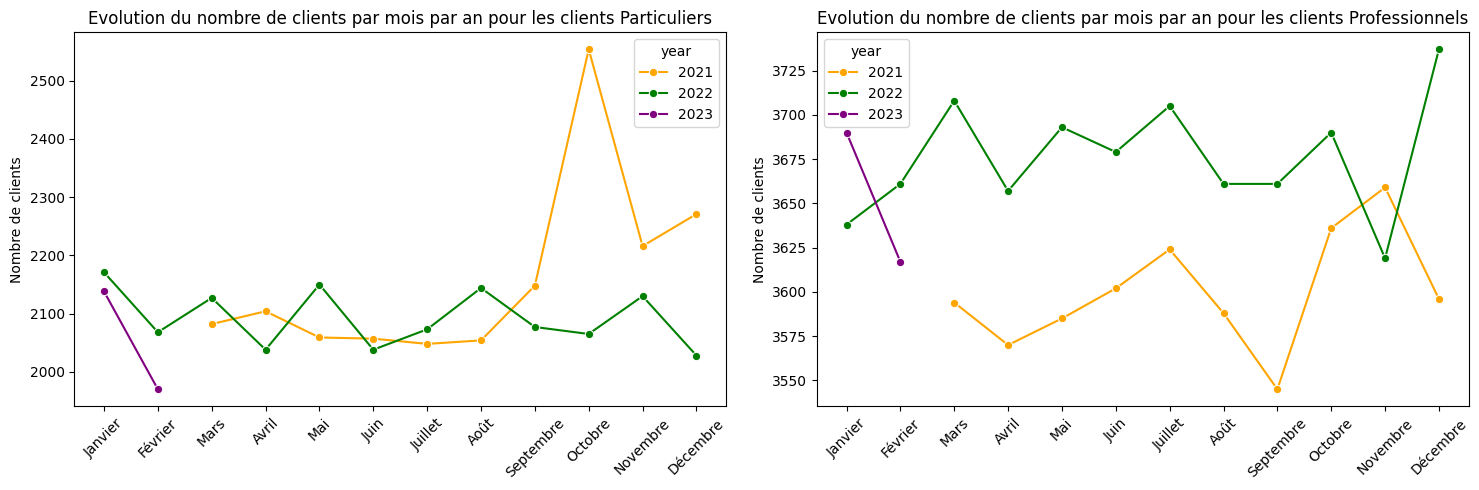

In [45]:
# Determine the évolution of the customers accross the months and years for the two categories
type_customers_evolution = customers_transactions_products_df.groupby(['year', 'month', 'type_customer'], as_index=False)['client_id'].nunique()
type_customers_evolution.sort_values(["year", "month"], ascending=True, inplace=True)

type_customers_evolution["month_name"] = month_number_to_name(type_customers_evolution["month"])

fig, ax = plt.subplots(1, type_customers_evolution['type_customer'].nunique(), figsize=(15, 5))
for i, type_customer in enumerate(type_customers_evolution['type_customer'].unique()):
  data_type_customer = type_customers_evolution[type_customers_evolution["type_customer"] == type_customer]
  ax[i].set_title(f'Evolution du nombre de clients par mois par an pour les clients {type_customer}')
  sns.lineplot(data=data_type_customer,
                 x='month_name',
                 y='client_id',
               hue='year',
               marker='o',
               ax=ax[i],
               palette=['orange', 'green', 'purple']) # Use palette instead of colors
  ax[i].set_xlabel('')
  ax[i].set_ylabel('Nombre de clients')
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45)
plt.subplots_adjust(wspace=0.8)
plt.tight_layout()
plt.show()

/tmp/ipython-input-2238772335.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('category', as_index=False)['price'].sum()


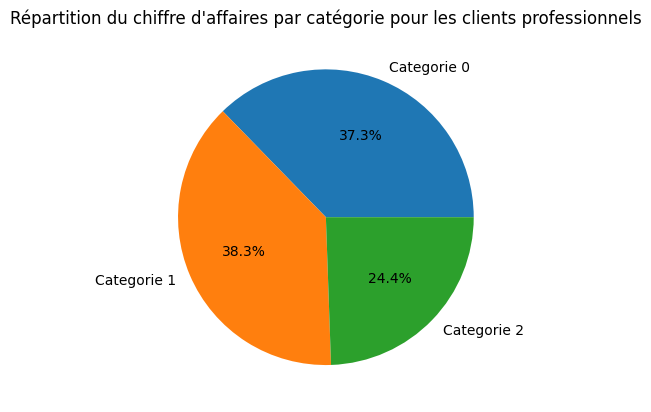

In [46]:
# Calculate the proportion of the price on the total turnover

# What are those customers

customer_revenue['prop_turnover'] = (customer_revenue['price']\
/ customer_revenue['price'].sum()).astype('float')*100

customer_category_revenue = customers_transactions_products_df[customers_transactions_products_df["type_customer"] == "Professionnels"]\
.groupby('category', as_index=False)['price'].sum()

plt.pie(data= customer_category_revenue,
        x="price",
                   labels=['Categorie ' + str(cat) for cat in customer_category_revenue["category"].unique()],
                   autopct='%1.1f%%')
plt.xlabel('')
plt.title('Répartition du chiffre d\'affaires par catégorie pour les clients professionnels')
plt.show()

In [47]:
# Their age also and their gender
customers_transactions_products_df = customers_transactions_products_df.merge(
    customer_revenue[['prop_turnover','client_id']], on='client_id')

In [48]:
# get rid of the top 4 customers
top_4_customers = customers_transactions_products_df.groupby('client_id', as_index=False)['price'].sum()\
.sort_values('price', ascending=False).head(4)
customers_transactions_products_less4_df = customers_transactions_products_df[~customers_transactions_products_df['client_id'].isin(top_4_customers['client_id'])]

# Corrélations

In [49]:
# definition of alpha = 0.05 to specify what is the variation accepted to determine
# whether or not a hypothesis is validated or not
alpha = 0.05

## Genre et catégorie



*   H0: Le genre et la catégorie de produits sont indépendents et ne s'influencent pas
*   H1: Le genre et la catégorie de produits sont dépendents

In [50]:
# Corr entre genre et catégories
from scipy.stats import chi2_contingency

cross_tab_sex_category = pd.crosstab(customers_transactions_products_less4_df['sex'], customers_transactions_products_less4_df['category'])
# Chi2 pour comparer si deux groupes sont indépendants ou non
chi2, pvalue, dof, expected = chi2_contingency(cross_tab_sex_category)

print(f'Khi2 value: {chi2:.2f}')
print(f'P-value: {pvalue}')

if pvalue < alpha:
    print('Hypothèse nulle rejetée : le "Genre" et la "Catégorie" semblent dépendants l\'un de l\'autre')
else:
    print('Nous ne pouvons pas rejeter l\'hypothèse nulle selon laquelle le "Genre" et la "Catégorie" sont indépendants')

Khi2 value: 22.88
P-value: 1.077858911273289e-05
Hypothèse nulle rejetée : le "Genre" et la "Catégorie" semblent dépendants l'un de l'autre


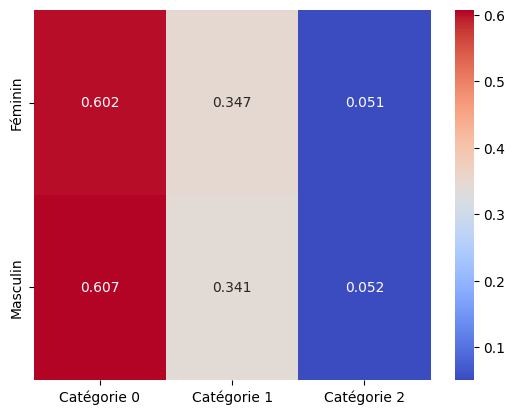

In [51]:
# Corrected colormap name
cross_tab_sex_category.index = ['Féminin', 'Masculin']
cross_tab_sex_category.columns = ['Catégorie 0', 'Catégorie 1', 'Catégorie 2']

# normalize the values to check how gender are distributed within categories
cross_sex_category_norm = cross_tab_sex_category.div(cross_tab_sex_category.sum(axis=1), axis=0)

sns.heatmap(cross_sex_category_norm, annot=True, cmap='coolwarm', fmt='.3f')
plt.show()

Les graphique ci-dessus montrent que le genre varie en fonction de la catégorie, ce qui valide la seconde hypothèse

In [52]:
# print the correlation
def display_correlation(method_value, pvalue, field1, field2):
    if pvalue < alpha:
      if method_value < 0:
        print(f'{field1} et le {field2} sont négativement corrélés')
      else:
        print(f'{field1} et le {field2} sont positivement corrélés')
    else:
        print(f'Échec du rejet de l\'hypothèse nulle : "{field1}" et "{field2}" ne semblent pas avoir de corrélation')

* H0: Il n'y a pas de corrélation entre l'âge et le montant total des achats
* H1: Il existe une corrélation positive ou négative entre l'âge et le montant total des achats

Coefficient de corrélation de Pearson : -0.83
Valeur p : 1.758948718207078e-20
Âge et le Montant total des achats sont négativement corrélés


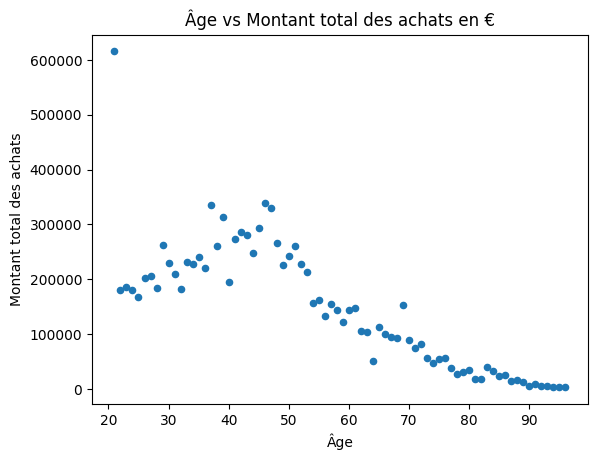

In [53]:
# Corrélation entre l'âge et le montant total des achats
age_total_purchase = customers_transactions_products_less4_df.groupby('age', as_index=False)['price'].sum()

# Pour comparer deux données quantitatives : corrélation de Pearson
from scipy.stats import pearsonr

pears, pvalue = pearsonr(age_total_purchase['age'], age_total_purchase['price'])

print(f'Coefficient de corrélation de Pearson : {pears:.2f}')
print(f'Valeur p : {pvalue}')

display_correlation(pears, pvalue, "Âge", "Montant total des achats")

# nous voulons afficher la manière dont ces deux valeurs sont corrélées
age_total_purchase.plot(kind='scatter', x='age', y='price')
plt.xlabel('Âge')
plt.ylabel('Montant total des achats')
plt.title('Âge vs Montant total des achats en €')
plt.show()

Le graphique en point montre que les deux valeurs sont corrélés négativement. Plus l'âge avance et plus le montant dépensé diminue.

## Corrélations entre l'âge et la fréquence d'achats

* H0: L'âge et la fréquence d'achat n'ont aucune corrélation et ne s'influencent pas.
* H1: L'âge et la fréquence d'achat sont corrélés et s'influenceront mutuellement.

Coefficient de corrélation de Pearson : -0.58
Valeur p : 4.7804157601143627e-08
Age et le Fréquence d'achats sont négativement corrélés


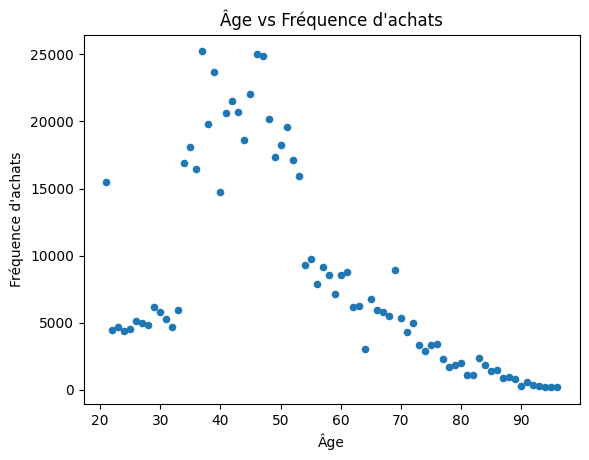

In [54]:
# Corr between age and purchases frequency

corr_age_frequency_grp = customers_transactions_products_less4_df.groupby('age', as_index=False)['date'].count()

pears, pvalue = pearsonr(corr_age_frequency_grp['age'], corr_age_frequency_grp['date'])

print(f'Coefficient de corrélation de Pearson : {pears:.2f}')
print(f'Valeur p : {pvalue}')

display_correlation(pears, pvalue, "Age", "Fréquence d'achats")

corr_age_frequency_grp.plot(kind='scatter', x='age', y='date')
plt.xlabel('Âge')
plt.ylabel("Fréquence d'achats")
plt.title("Âge vs Fréquence d'achats")
plt.show()

## Corrélation entre l'âge et les achats moyens

* H0: Aucune corrélation entre l'âge et les achats moyens
* H1: L'âge et les achats moyens sont corrélés

Coefficient de corrélation de Pearson : -0.54
Valeur p : 3.6931144478345896e-07
Âge et le Achats moyens sont négativement corrélés


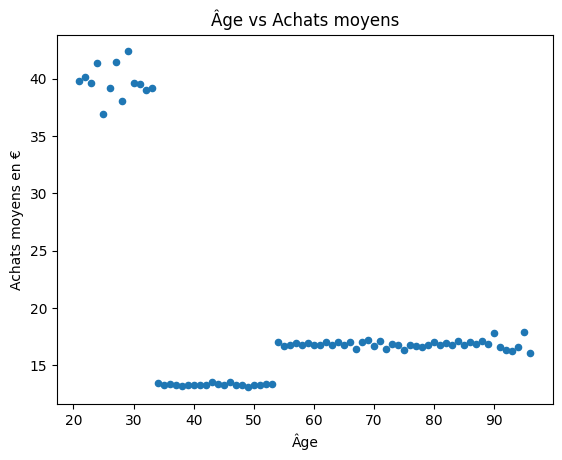

In [55]:
# Corrélation entre l'âge et les achats moyens
corr_age_avg_purchases_grp = customers_transactions_products_less4_df.groupby('age', as_index=False)['price'].mean()

pears, pvalue = pearsonr(corr_age_avg_purchases_grp['age'], corr_age_avg_purchases_grp['price'])

print(f'Coefficient de corrélation de Pearson : {pears:.2f}')
print(f'Valeur p : {pvalue}')

display_correlation(pears, pvalue, "Âge", "Achats moyens")

corr_age_avg_purchases_grp.plot(kind='scatter', x='age', y='price')
plt.xlabel('Âge')
plt.ylabel('Achats moyens en €')
plt.title('Âge vs Achats moyens')
plt.show()

La corrélation via Pearson nous montre une corrélation négative entre l'âge et le prix. Plus les personnes sont âgés et moins ils vont être enclins à dépenser.

## Corrélation entre l'âge et la catégorie

*   H0: pas de differences d'âge entre les différentes catégories
*   H1: Il y a au moins une variation d'âge entre les catégories




In [56]:
# Relation between age and category

# Use of Anova to compare one category and one quantitative data for more than 2 groups
from scipy.stats import f_oneway

group0 = customers_transactions_products_less4_df[customers_transactions_products_less4_df['category'] == 0]['age']
group1 = customers_transactions_products_less4_df[customers_transactions_products_less4_df['category'] == 1]['age']
group2 = customers_transactions_products_less4_df[customers_transactions_products_less4_df['category'] == 2]['age']

foneway, pvalue = f_oneway(group0, group1, group2)

print(f"Test d'ANOVA: {foneway:.2f}")
print(f'P-value: {pvalue}')

if pvalue < alpha:
    print('Il existe au moins une différence d\'âge entre les catégories')
else:
    print('Pas de preuve solide qu\'il existe une différence entre les catégories')

Test d'ANOVA: 39569.02
P-value: 0.0
Il existe au moins une différence d'âge entre les catégories


In [57]:
# I will use now kruskal to confirm the hypothesis from Anova to compare the distribution of more than 2 groups
from scipy.stats import kruskal

kruskal, pvalue = kruskal(group0, group1, group2)

print(f'Statistique de Kruskal : {kruskal:.2f}')
print(f'Valeur p : {pvalue}')

if pvalue < alpha:
    print('Il existe au moins une différence d\'âge entre les catégories')
else:
    print('Pas de preuve solide qu\'il existe une différence entre les catégories')

Statistique de Kruskal : 71134.91
Valeur p : 0.0
Il existe au moins une différence d'âge entre les catégories


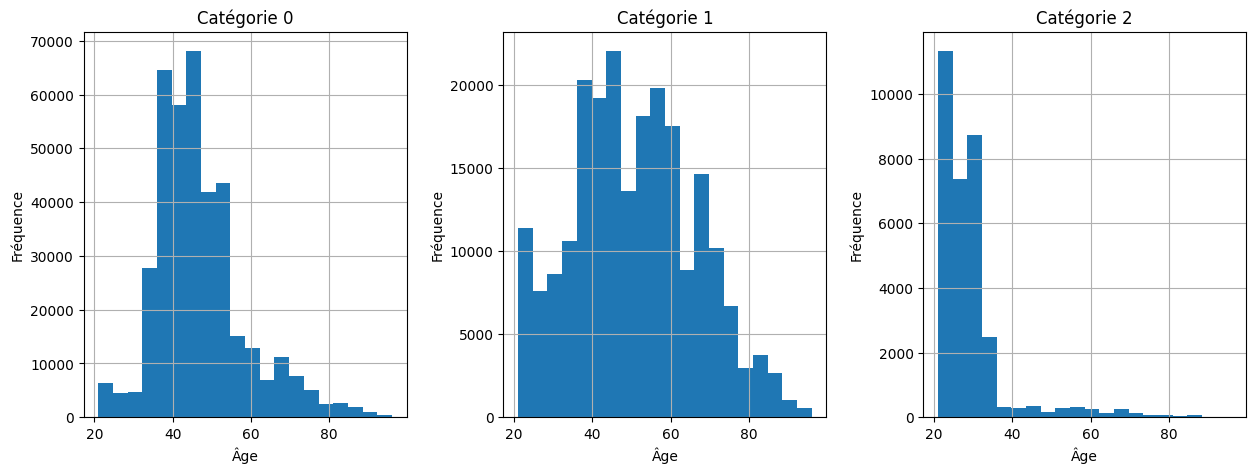

In [58]:
# We can also check the distribution of each category to see
len_category = len(customers_transactions_products_less4_df['category'].unique())

# I need to draw the number of subplots to display
fig, axes = plt.subplots(1, len_category, figsize=(15, 5))

for i, ax in enumerate(axes.flat):
  distribution_age_category = customers_transactions_products_less4_df.loc[customers_transactions_products_less4_df['category'] == i, ['age']]
  distribution_age_category.hist(ax=ax, bins=20)
  ax.set_xlabel('Âge')
  ax.set_ylabel('Fréquence')
  ax.set_title(f'Catégorie {i}')

plt.show()

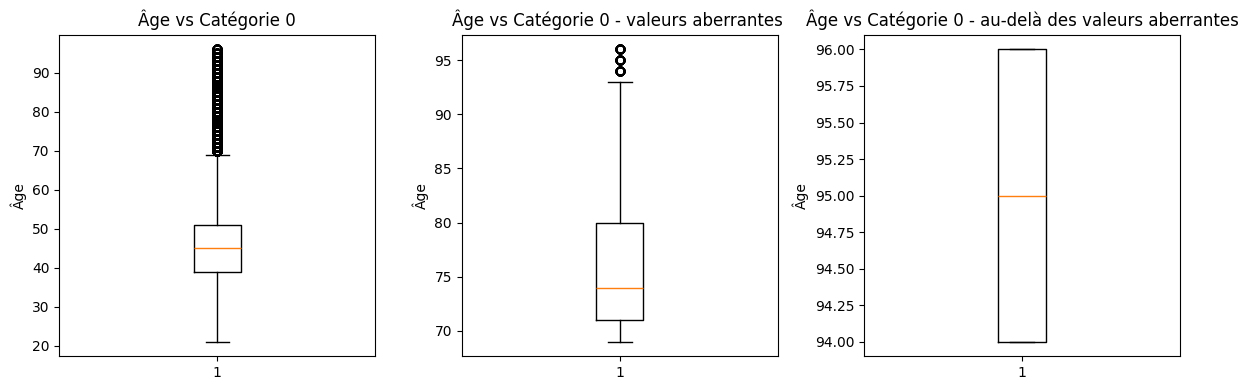

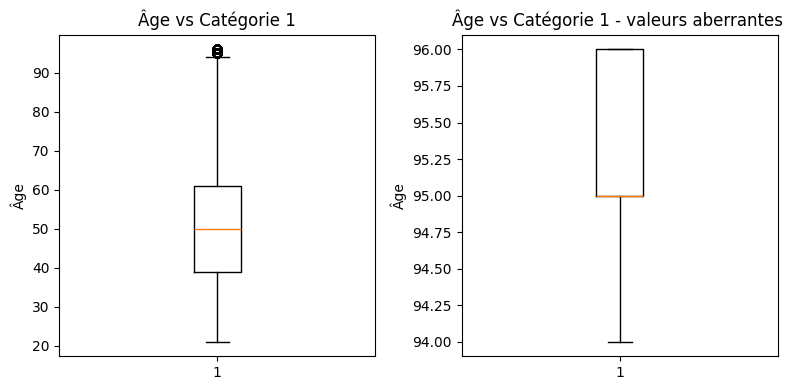

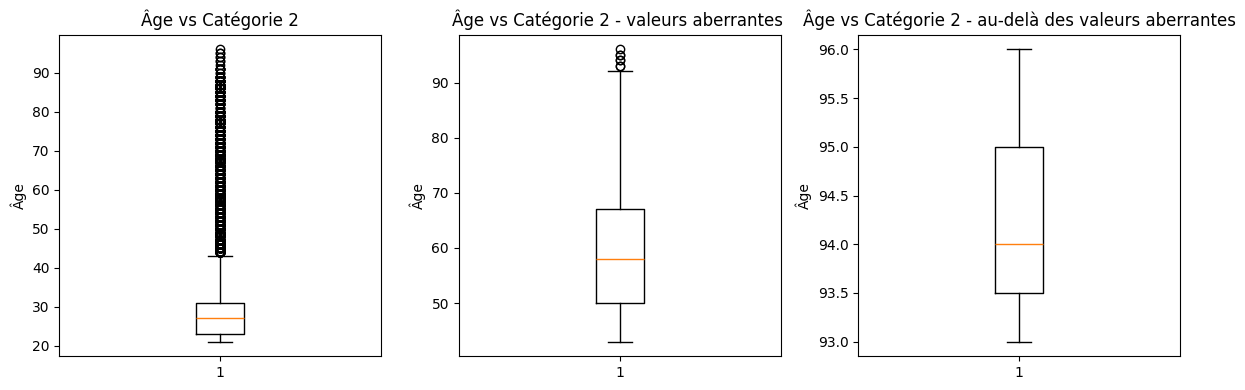

In [59]:
for cat in customers_transactions_products_less4_df["category"].unique():
  # Calculate the iqr and the quantiles
  subset_normal = customers_transactions_products_less4_df[customers_transactions_products_less4_df["category"] == cat]

  # Calculate and subset the plot for outliers
  iqr, lower_whisker, upper_whisker = calculate_iqr(subset_normal, 'age')
  subset_higher = subset_normal[(subset_normal["category"] == cat) & (subset_normal["age"] >= upper_whisker)]

  # Calculate the IQR of the next dataset only if the previous one is not empty
  if not subset_higher.empty:
    iqr_even_higher, lower_whisker_even_higher, upper_whisker_even_higher = calculate_iqr(subset_higher, 'age')
    subset_even_higher = subset_higher[(subset_higher["category"] == cat) & (subset_higher["age"] >= upper_whisker_even_higher)]

  levels = [subset_normal, subset_higher, subset_even_higher]

  fig, ax = plt.subplots(1, len(levels), figsize=(12, 4))
  for i, data in enumerate(levels):
    if data.empty:
      ax[i].set_visible(False)
    else:
      ax[i].boxplot(data["age"])
      if i == 0:
        title = f'Âge vs Catégorie {cat}'
      elif i == 1:
        title = f'Âge vs Catégorie {cat} - valeurs aberrantes '
      else:
        title = f'Âge vs Catégorie {cat} - au-delà des valeurs aberrantes'
      ax[i].set_title(title)
      ax[i].set_ylabel('Âge')

  plt.tight_layout()
  plt.show()

Grâce à tous les graphiques ci-dessus, nous pouvons confirmer notre précédent test d'hypothèse selon lequel la tranche d'âge varie en fonction de la catégorie. À l'exception des deux premières catégories qui semblent un peu mieux réparties, on remarque que la deuxième catégorie est la plus déséquilibrée, regroupant principalement les personnes âgées de 20 à 35 ans.